In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, f1_score
import numpy as np

In [3]:
# Load the data
df = pd.read_csv("..\data\processed\MAYBANK_preprocessed.csv", parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.tail()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\lunwe\AppData\Local\Temp\ipykernel_24912\233000206.py:2: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("..\data\processed\MAYBANK_preprocessed.csv", parse_dates=['Date'])


,Open,High,Low,Close,Volume,Return,MA5,MA10,Volatility,Target
Date,,,,,,,,,,
2025-08-25,9.85,9.90,9.83,9.85,17724500,0.005102,9.806,9.802,0.002661,0
2025-08-26,9.85,9.88,9.75,9.75,81816700,-0.010152,9.796,9.806,0.005752,1
2025-08-27,9.78,9.83,9.72,9.79,7930800,0.004103,9.794,9.799,0.006207,1
2025-08-28,9.83,9.98,9.83,9.95,11065300,0.016343,9.828,9.810,0.009439,0
2025-08-29,9.95,9.95,9.86,9.90,15268300,-0.005025,9.848,9.820,0.010208,0


In [4]:
# Base predictors
predictors = ["Close", "Volume", "Open", "High", "Low", "Return", "MA5", "MA10", "Volatility"]

In [5]:
# Feature engineering
df["weekly_mean"] = df["Close"].rolling(7).mean() / df["Close"]
df["quarterly_mean"] = df["Close"].rolling(90).mean() / df["Close"]
df["annual_mean"] = df["Close"].rolling(365).mean() / df["Close"]
df["annual_weekly_mean"] = df["annual_mean"] / df["weekly_mean"]
df["annual_quarterly_mean"] = df["annual_mean"] / df["quarterly_mean"]
df["weekly_trend"] = df["Target"].shift(1).rolling(7).sum()
df["open_close_ratio"] = df["Open"] / df["Close"]
df["high_close_ratio"] = df["High"] / df["Close"]
df["low_close_ratio"] = df["Low"] / df["Close"]

# Full predictor set
full_predictors = predictors + [
    "weekly_mean", "quarterly_mean", "annual_mean",
    "annual_weekly_mean", "annual_quarterly_mean",
    "open_close_ratio", "high_close_ratio", "low_close_ratio", "weekly_trend"
]

In [6]:
# Drop missing values caused by rolling calculations
df = df.dropna()

# Backtest with a given threshold
def backtest(data, model, predictors, threshold=0.46, start=200, step=250):
    predictions = []
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i]
        test = data.iloc[i:(i+step)]
        model.fit(train[predictors], train["Target"])
        preds = model.predict_proba(test[predictors])[:, 1]
        preds_bin = (preds > threshold).astype(int)
        combined = pd.DataFrame({
            "Target": test["Target"],
            "Predictions": preds_bin
        }, index=test.index)
        predictions.append(combined)
    return pd.concat(predictions)

In [11]:
if __name__ == "__main__":
    # Fixed best hyperparameters (from your previous run)
    best_params = {
        'n_estimators': 900,
        'min_samples_split': 5,
        'min_samples_leaf': 3,
        'max_features': 'log2',
        'max_depth': None,
        'class_weight': None
    }

    # Initialize the Random Forest model with the best hyperparameters
    model = RandomForestClassifier(**best_params, random_state=42)

    # Backtest with the best threshold found previously (0.45)
    predictions = backtest(df, model, full_predictors, threshold=0.45)

    # Evaluate performance
    precision = precision_score(predictions["Target"], predictions["Predictions"])
    f1 = f1_score(predictions["Target"], predictions["Predictions"])
    print(f"Final Precision: {precision:.8f}")
    print(f"Final F1 Score: {f1:.4f}")
    print(f"Number of Buys: {predictions['Predictions'].sum()}")

Final Precision: 0.52941176
Final F1 Score: 0.4151
Number of Buys: 187


In [9]:
# Check how many trades would have been made
trade_counts = predictions["Predictions"].value_counts()
print(f"Trade Counts:\n{trade_counts}")

Trade Counts:
Predictions
0    466
1    187
Name: count, dtype: int64


<Axes: title={'center': 'Last 100 Predictions'}, xlabel='Date'>

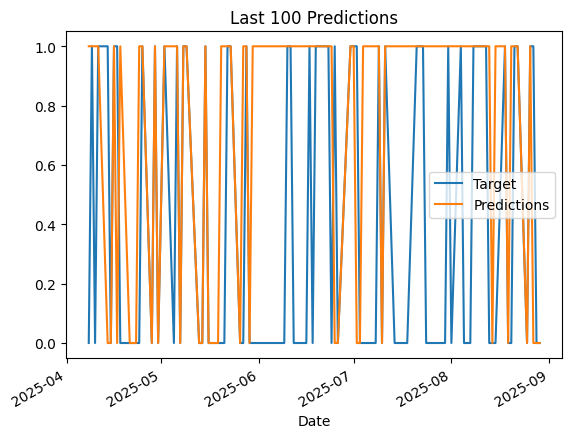

In [10]:
# Plot the last 100 predictions to visualize the model's performance
predictions.iloc[-100:].plot(title="Last 100 Predictions")